# Markov Simulation of a Food Truck Work Process

This notebook models a simple food truck work process using a Markov chain.  

The process has four possible states:

1. **Customer Service**
2. **Restocking**
3. **Cooking**
4. **Cleaning**

At each step, the system moves from the current task to the next task according to a transition probability matrix.  
The goal is to simulate the process over time, estimate the long-run task distribution, and compare the simulated transition behavior to the original Markov matrix.

An optional extension is included at the end to model equipment condition and equipment breakdowns — I wanted more experience working with Markov. 


## Narrative of the Process

This model represents a food truck worker moving between common operating tasks during a shift. The worker may serve a customer, restock supplies, cook food, or clean the workspace. Each task is treated as a process state.

The Markov assumption is that the next task depends only on the current task, not on the full history of previous tasks. For example, after cooking, the worker may be more likely to continue cooking or switch to cleaning, depending on the transition probabilities.

The model uses symbolic object labels to resemble the real-world process:

| State | Meaning |
|---|---|
| Customer Service | Helping customers or using the POS system |
| Restocking | Checking or replacing supplies |
| Cooking | Preparing food using cooking equipment |
| Cleaning | Cleaning the workspace |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


## State Definitions and Transition Matrix

The transition matrix gives the probability of moving from one task to another.

Each row represents the current state.  
Each column represents the next state.  
Each row must sum to 1.


In [2]:
states = ["Customer Service", "Restocking", "Cooking", "Cleaning"]

P = np.array([
    [0.20, 0.10, 0.60, 0.10],  # Customer Service
    [0.65, 0.00, 0.15, 0.20],  # Restocking
    [0.15, 0.35, 0.10, 0.40],  # Cooking
    [0.70, 0.15, 0.15, 0.00]   # Cleaning
])

transition_df = pd.DataFrame(P, index=states, columns=states)
transition_df


,Customer Service,Restocking,Cooking,Cleaning
Customer Service,0.20,0.10,0.60,0.1
Restocking,0.65,0.00,0.15,0.2
Cooking,0.15,0.35,0.10,0.4
Cleaning,0.70,0.15,0.15,0.0


In [3]:
# Confirm that each row of the matrix sums to 1
row_sums = P.sum(axis=1)
pd.DataFrame({"State": states, "Row Sum": row_sums})


,State,Row Sum
0,Customer Service,1.0
1,Restocking,1.0
2,Cooking,1.0
3,Cleaning,1.0


## Markov Chain Simulation

The simulation starts in **Customer Service** and then repeatedly selects the next task using the transition probabilities from the current task.


In [4]:
def sample_next_state(probabilities, rng):
    '''
    selects the next state index using a probability vector.
    '''
    return rng.choice(len(probabilities), p=probabilities)


n_steps = 5000

# tracks how often each state-to-state transition occurs
state_change_hist = np.zeros((len(states), len(states)))

# tracks how often each state appears
state_counts = np.zeros(len(states))

# start at customer service
current_state = 0

state_history = [current_state]
distribution_history = []

for step in range(n_steps):
    # use the current state's row in the transition matrix
    current_row = P[current_state]
    next_state = sample_next_state(current_row, rng)

    # count the transition from current state to next state
    state_change_hist[current_state, next_state] += 1
    state_counts[next_state] += 1

    current_state = next_state
    state_history.append(current_state)

    # update the running distribution of states
    counts_so_far = np.bincount(state_history, minlength=len(states))
    distribution = counts_so_far / counts_so_far.sum()
    distribution_history.append(distribution)

final_distribution = distribution_history[-1]

final_distribution_df = pd.DataFrame({
    "State": states,
    "Final Simulated Distribution": final_distribution
})

final_distribution_df

,State,Final Simulated Distribution
0,Customer Service,0.357928
1,Restocking,0.169566
2,Cooking,0.287742
3,Cleaning,0.184763


## Estimated Transition Matrix from the Simulation

This matrix estimates the transition probabilities observed during the simulation.  
It should be close to the original transition matrix if the simulation ran long enough.


In [5]:
P_hat = state_change_hist / state_change_hist.sum(axis=1, keepdims=True)

estimated_transition_df = pd.DataFrame(P_hat, index=states, columns=states)
estimated_transition_df


,Customer Service,Restocking,Cooking,Cleaning
Customer Service,0.211291,0.101174,0.591951,0.095584
Restocking,0.646226,0.000000,0.149764,0.204009
Cooking,0.141070,0.366227,0.089646,0.403058
Cleaning,0.714286,0.151515,0.134199,0.000000


In [6]:
comparison_df = pd.DataFrame({
    "State": states,
    "Original Distribution Estimate": transition_df.mean(axis=0).values,
    "Final Simulated Distribution": final_distribution
})

comparison_df


,State,Original Distribution Estimate,Final Simulated Distribution
0,Customer Service,0.425,0.357928
1,Restocking,0.150,0.169566
2,Cooking,0.250,0.287742
3,Cleaning,0.175,0.184763


The simulated distribution is close to the rough original estimate, though `Cooking` is a bit higher and `Customer Service` is a bit lower. Overall, seems fair. 

## Full Markov Simulation

If we combine everything under a single definition: 

In [7]:
def run_markov_simulation(P, states, n_steps=5000, seed=42, start_state=0):
    '''
    runs a markov chain simulation and returns summary tables.
    '''

    rng = np.random.default_rng(seed)

    def sample_next_state(probabilities):
        return rng.choice(len(probabilities), p=probabilities)

    # tracks how often each state-to-state transition occurs
    state_change_hist = np.zeros((len(states), len(states)))

    # tracks how often each state appears
    state_counts = np.zeros(len(states))

    current_state = start_state
    state_history = [current_state]
    distribution_history = []

    for step in range(n_steps):
        # use the current state's row in the transition matrix
        current_row = P[current_state]
        next_state = sample_next_state(current_row)

        # count the transition from current state to next state
        state_change_hist[current_state, next_state] += 1
        state_counts[next_state] += 1

        current_state = next_state
        state_history.append(current_state)

        # update the running distribution of states
        counts_so_far = np.bincount(state_history, minlength=len(states))
        distribution = counts_so_far / counts_so_far.sum()
        distribution_history.append(distribution)

    final_distribution = distribution_history[-1]

    final_distribution_df = pd.DataFrame({
        "State": states,
        "Final Simulated Distribution": final_distribution
    })

    # estimated transition matrix from the simulation
    P_hat = state_change_hist / state_change_hist.sum(axis=1, keepdims=True)

    estimated_transition_df = pd.DataFrame(
        P_hat,
        index=states,
        columns=states
    )

    # compares final simulation results to average incoming transition probabilities
    transition_df = pd.DataFrame(P, index=states, columns=states)

    comparison_df = pd.DataFrame({
        "State": states,
        "Average Incoming Transition Probability": transition_df.mean(axis=0).values,
        "Final Simulated Distribution": final_distribution
    })

    distribution_df = pd.DataFrame(distribution_history, columns=states)

    return {
        "final_distribution_df": final_distribution_df,
        "estimated_transition_df": estimated_transition_df,
        "comparison_df": comparison_df,
        "distribution_df": distribution_df,
        "state_history": state_history,
        "state_change_hist": state_change_hist
    }

In [8]:
results = run_markov_simulation(P, states, n_steps=5000, seed=42)
results["final_distribution_df"]

,State,Final Simulated Distribution
0,Customer Service,0.357928
1,Restocking,0.169566
2,Cooking,0.287742
3,Cleaning,0.184763


In [9]:
results["estimated_transition_df"]

,Customer Service,Restocking,Cooking,Cleaning
Customer Service,0.211291,0.101174,0.591951,0.095584
Restocking,0.646226,0.000000,0.149764,0.204009
Cooking,0.141070,0.366227,0.089646,0.403058
Cleaning,0.714286,0.151515,0.134199,0.000000


In [10]:
results["comparison_df"]

,State,Average Incoming Transition Probability,Final Simulated Distribution
0,Customer Service,0.425,0.357928
1,Restocking,0.150,0.169566
2,Cooking,0.250,0.287742
3,Cleaning,0.175,0.184763


## Distribution Over Time

The following plot shows how the estimated distribution of tasks changes as the simulation progresses.


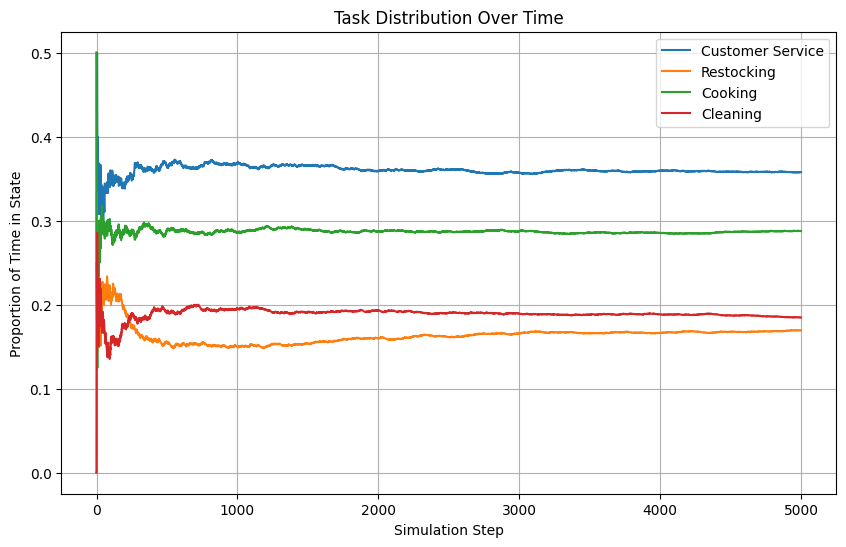

In [11]:
results["distribution_df"].plot(
    title="Task Distribution Over Time",
    figsize=(10, 6)
)

plt.xlabel("Simulation Step")
plt.ylabel("Proportion of Time in State")
plt.grid(True)
plt.show()

This plot shows the simulated state distribution stabilizing over time. The early steps fluctuate because the sample size is still small, but after several hundred steps the proportions level out. Customer Service remains the most common state, Cooking is second, and Restocking and Cleaning settle at lower proportions. This suggests the Markov chain is reaching a stable long-run behavior.

Customer Service appears most often because the worker frequently returns to the service window after support tasks. Cooking may still take more total time because cooking tasks have longer durations than customer service tasks.

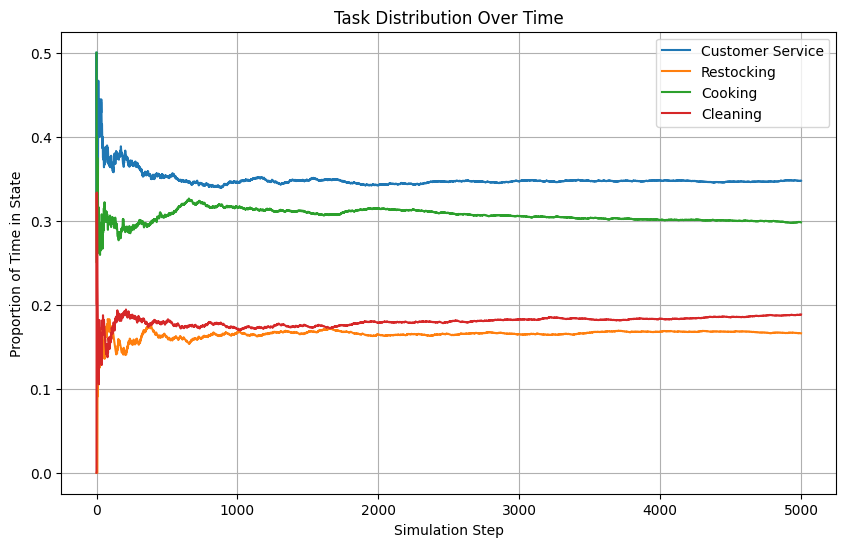

In [12]:
results = run_markov_simulation(P, states, n_steps=5000, seed=8)
results["distribution_df"].plot(
    title="Task Distribution Over Time",
    figsize=(10, 6)
)

plt.xlabel("Simulation Step")
plt.ylabel("Proportion of Time in State")
plt.grid(True)
plt.show()

This plot shows that the Markov simulation still settles into a stable pattern even when a different random seed is used. The exact path changes because the simulation is random, but the long-run proportions remain similar. Customer Service and Cooking stay as the two most common states, while Restocking and Cleaning remain lower. This supports the idea that the transition matrix controls the overall behavior, while the seed only changes the specific random sequence.

## Task Count Summary

This table shows how often each task occurred in the simulation.


In [13]:
task_count_df = pd.DataFrame({
    "State": states,
    "Count": np.bincount(state_history, minlength=len(states)),
    "Percent": np.bincount(state_history, minlength=len(states)) / len(state_history)
})

task_count_df


,State,Count,Percent
0,Customer Service,1790,0.357928
1,Restocking,848,0.169566
2,Cooking,1439,0.287742
3,Cleaning,924,0.184763


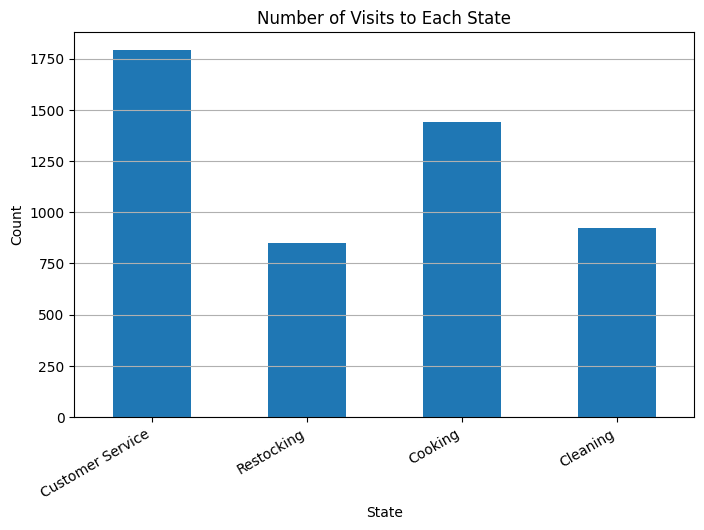

In [14]:
task_count_df.set_index("State")["Count"].plot(kind="bar", title="Number of Visits to Each State", figsize=(8, 5))
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()


This chart shows the number of visits to each process state during the Markov simulation before adding equipment effects. Customer Service occurs most often, followed by Cooking. Restocking and Cleaning occur less frequently, which matches the transition matrix because the model tends to move back toward Customer Service after support tasks.

## Included Extension: Equipment Condition

The required model has four process states. This extension adds equipment condition as a supporting feature.

Each task uses a piece of equipment:

| Task | Equipment |
|---|---|
| Customer Service | POS System |
| Restocking | Restocking Sheet |
| Cooking | Pan |
| Cleaning | Rag |

Equipment condition is represented using four states:

1. New
2. Good
3. Worn
4. Broken

When equipment breaks, replacement time is added and the equipment resets to **New**.


In [15]:
# matches each task to the equipment used during that task
equipment_for_task = {
    "Customer Service": "POS System",
    "Restocking": "Restocking Sheet",
    "Cooking": "Pan",
    "Cleaning": "Rag"
}

# possible condition states for each piece of equipment
equipment_states = ["New", "Good", "Worn", "Broken"]

def make_equipment_matrix(break_prob, degrade_prob):
    '''
    creates a transition matrix for equipment condition.
    rows are current condition.
    columns are next condition.
    '''

    # probability that equipment stays in the same condition
    stay_new = 1 - degrade_prob - break_prob
    stay_good = 1 - degrade_prob - break_prob
    stay_worn = 1 - break_prob

    # transition matrix for equipment condition
    return np.array([
        [stay_new, degrade_prob, 0.0, break_prob],   # new
        [0.0, stay_good, degrade_prob, break_prob],  # good
        [0.0, 0.0, stay_worn, break_prob],           # worn
        [1.0, 0.0, 0.0, 0.0]                         # broken
    ])

# equipment transition matrices
P_equipment = {
    "POS System": make_equipment_matrix(break_prob=0.01, degrade_prob=0.03),
    "Restocking Sheet": make_equipment_matrix(break_prob=0.30, degrade_prob=0.20),
    "Pan": make_equipment_matrix(break_prob=0.01, degrade_prob=0.05),
    "Rag": make_equipment_matrix(break_prob=0.20, degrade_prob=0.50)
}

# time needed to replace each piece of equipment, in minutes
replace_times_minutes = {
    "POS System": 30.0,
    "Restocking Sheet": 0.5,
    "Pan": 5.0,
    "Rag": 1 / 6
}

# time range for each task, in minutes
task_time_ranges_minutes = {
    "Customer Service": (1.0, 3.0),
    "Restocking": (1.0, 2.0),
    "Cooking": (2.0, 5.0),
    "Cleaning": (0.5, 1.0)
}

## Simulating Work Time with Equipment Breakdowns

This section simulates continuous work and tracks total time.
 
Results can be normalized to a 9-hour workday instead of creating separate day-specific simulations.


In [16]:
rng = np.random.default_rng(42)

target_minutes = 9 * 60
total_time = 0.0
step = 0

# start the process at customer service
current_task_index = 0

# all equipment starts as new, which is condition 1
equipment_condition = {
    "POS System": 1,
    "Restocking Sheet": 1,
    "Pan": 1,
    "Rag": 1
}

equipment_breaks = {equipment: 0 for equipment in equipment_condition}
equipment_records = []

while total_time < target_minutes:
    task = states[current_task_index]
    equipment = equipment_for_task[task]

    # randomly choose the duration for the current task
    low, high = task_time_ranges_minutes[task]
    task_duration = rng.uniform(low, high)
    total_time += task_duration

    # use the current equipment condition to choose its next condition
    current_condition = equipment_condition[equipment]
    equipment_row = P_equipment[equipment][current_condition - 1]
    next_condition = sample_next_state(equipment_row, rng) + 1

    # condition 4 means the equipment broke and needs replacement
    broke = False
    if next_condition == 4:
        broke = True
        equipment_breaks[equipment] += 1
        total_time += replace_times_minutes[equipment]
        next_condition = 1

    equipment_condition[equipment] = next_condition

    # save one row of simulation data
    equipment_records.append({
        "Step": step,
        "Task": task,
        "Equipment": equipment,
        "Task Duration": task_duration,
        "Equipment Broke": broke,
        "Equipment Condition After": equipment_states[next_condition - 1],
        "Total Time": total_time
    })

    # choose the next task using the main markov matrix
    current_task_index = sample_next_state(P[current_task_index], rng)
    step += 1

equipment_df = pd.DataFrame(equipment_records)

equipment_df.round({
    "Task Duration": 2,
    "Total Time": 2
}).head(10)

equipment_df.head(10)

,Step,Task,Equipment,Task Duration,Equipment Broke,Equipment Condition After,Total Time
0,0,Customer Service,POS System,2.547912,False,New,2.547912
1,1,Cooking,Pan,4.092104,False,New,6.640016
2,2,Cleaning,Rag,0.880570,False,Good,7.520586
3,3,Customer Service,POS System,1.900772,False,New,9.421358
4,4,Cleaning,Rag,0.821933,True,New,10.409957
5,5,Customer Service,POS System,1.454477,False,New,11.864435
6,6,Customer Service,POS System,2.655262,False,New,14.519697
7,7,Cooking,Pan,3.063578,False,Good,17.583275
8,8,Cleaning,Rag,0.889192,False,New,18.472467
9,9,Customer Service,POS System,1.087608,False,New,19.560074


After the first 10 simulated tasks, the total elapsed work time is about 19.56 minutes. The model shows the worker moving from customer service into cooking and then cleaning, which matches the transition logic. The rag also breaks once during cleaning and is immediately replaced, resetting its condition to New.

In [17]:
print("Total simulated time:", round(total_time, 2), "minutes")
print("Total simulated time:", round(total_time / 60, 2), "hours")
print("Number of completed tasks:", len(equipment_df))

break_summary_df = pd.DataFrame({
    "Equipment": list(equipment_breaks.keys()),
    "Breaks": list(equipment_breaks.values())
})

break_summary_df


Total simulated time: 540.39 minutes
Total simulated time: 9.01 hours
Number of completed tasks: 242


,Equipment,Breaks
0,POS System,0
1,Restocking Sheet,13
2,Pan,1
3,Rag,7


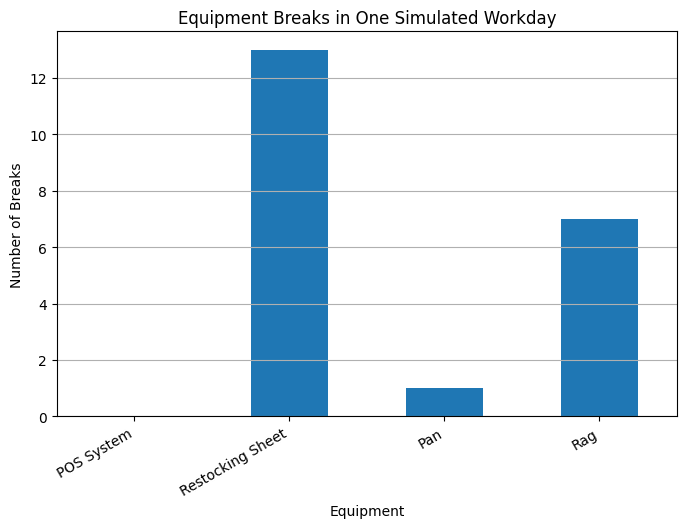

In [18]:
break_summary_df.set_index("Equipment")["Breaks"].plot(kind="bar", title="Equipment Breaks in One Simulated Workday", figsize=(8, 5))
plt.xlabel("Equipment")
plt.ylabel("Number of Breaks")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()


During the simulated 9-hour workday, the Restocking Sheet broke the most often with 13 breaks, followed by the Rag with 7 breaks. The Pan broke once, while the POS System did not break during this run. This matches the assigned breakdown probabilities, since the Restocking Sheet and Rag have higher failure rates than the Pan and POS System.

## Conclusion

The simulation represents a four-state restaurant work process using Markov chain logic. The transition matrix controls movement between Customer Service, Restocking, Cooking, and Cleaning. Over many steps, the simulated state distribution approaches the long-run behavior implied by the transition probabilities.

The optional equipment extension adds realism by tracking whether the tools used for each task remain usable or break during the process. However, the main Markov model remains focused on the four required process states.
